--- Pokretanje dva prepletena kvantna neurona ---


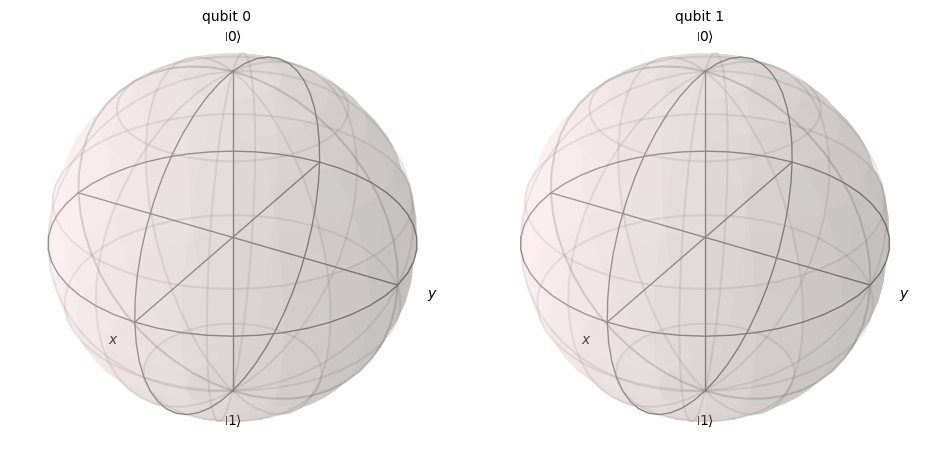

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

print("--- Pokretanje dva prepletena kvantna neurona ---")

# 1. Pravimo kolo sa dva kubita (dva neurona)
kolo_mreza = QuantumCircuit(2)

# 2. Definišemo parametre učenja (težine) za oba neurona
w1 = Parameter('w1')
w2 = Parameter('w2')

# 3. Neuron 1 (kubit 0) i Neuron 2 (kubit 1) dobijaju svoje rotacije
kolo_mreza.ry(w1, 0)
kolo_mreza.ry(w2, 1)

# 4. KLJUČNI KORAK: Preplećemo neurone pomoću CNOT kapije (cx)
# Kubit 0 kontroliše ponašanje kubita 1
kolo_mreza.cx(0, 1)

# 5. SIMULIRAMO REZULTAT UČENJA
# Zamislimo da je AI izračunao da su idealni uglovi: w1 = 90 stepeni, w2 = 0 stepeni
ugao_w1 = 90 * (np.pi / 180)
ugao_w2 = 0 * (np.pi / 180)

naucena_mreza = kolo_mreza.assign_parameters({w1: ugao_w1, w2: ugao_w2})

# 6. Izvlačimo stanje i crtamo DVE Blohove sfere istovremeno
stanje_mreze = Statevector.from_instruction(naucena_mreza)
prikaz_mreze = plot_bloch_multivector(stanje_mreze)

plt.show()
prikaz_mreze


Zašto nema strelica na crtežu? 

Strelice su nestale jer se sistem nalazi u stanju maksimalne kvantne prepletenosti (Maximally Entangled State), gde pojedinačni kubiti gube svoj nezavisni matematički identitet i kolabiraju u centar Blohove sfere.

Koja funkcija je izbrisala strelice? 

Komanda "kolo_mreza.cx(0, 1)" (CNOT kapija) pretvorila je dva odvojena sistema u jedno zajedničko Belovo stanje (Bell State), 
što uzrokuje da parcijalna matrica gustine svakog pojedinačnog kubita postane maksimalno pomešana.

Šta ovo praktično znači za Kvantni AI? 

Prazne sfere su vizuelni dokaz da naš kvantni AI ne analizira podatke odvojeno (jedan po jedan), već koristi kvantne korelacije da posmatra ceo mrežni saobraćaj kao jednu jedinstvenu celinu kroz Hilbertov prostor, što klasični računari hardverski ne mogu da simuliraju.